In [0]:
fligths_df = spark.read.table('flights')
bookings_df = spark.read.table('bookings')
preferences_df = spark.read.table('preferences')

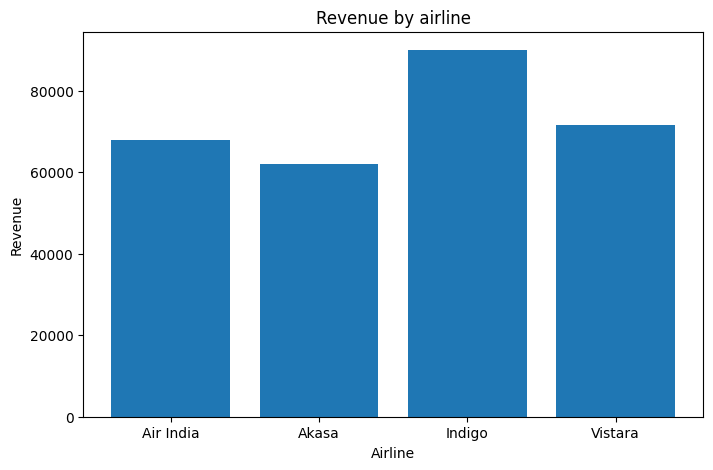

In [0]:
from matplotlib import pyplot as plt 
from pyspark.sql.functions import *

rev_by_airline = bookings_df.join(
    fligths_df,
    'flight_id',
    'left'
).groupBy('airline').agg(sum('ticket_price').alias('revenue'))

rev_by_airline = rev_by_airline.toPandas()

plt.figure(figsize=(8,5))
plt.bar(rev_by_airline['airline'], rev_by_airline['revenue'])
plt.title('Revenue by airline')
plt.xlabel('Airline')
plt.ylabel('Revenue')
plt.show()

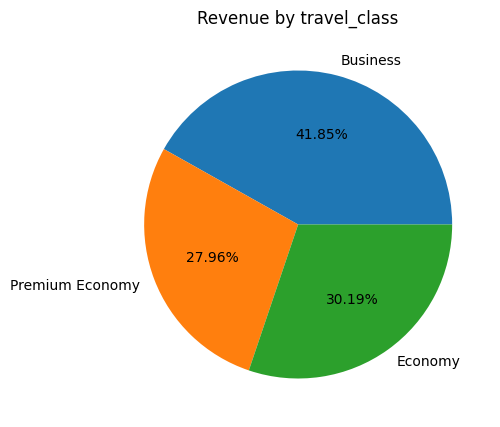

In [0]:
rev_by_class = bookings_df.join(
    fligths_df,
    'flight_id',
    'left'
).groupBy('travel_class').agg(sum('ticket_price').alias('revenue'))

rev_by_class = rev_by_class.toPandas()

plt.figure(figsize=(8,5))
plt.pie(
    rev_by_class['revenue'],
    labels=rev_by_class['travel_class'],
    autopct='%.2f%%'
)
plt.title('Revenue by travel_class')
plt.show()

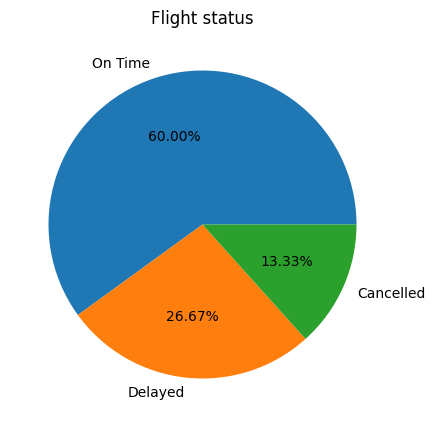

In [0]:
flight_by_status = fligths_df.groupBy('status').count()

flight_by_status = flight_by_status.toPandas()

plt.figure(figsize=(8,5))
plt.pie(
    flight_by_status['count'],
    labels=flight_by_status['status'],
    autopct='%.2f%%'
)
plt.title('Flight status')
plt.show()

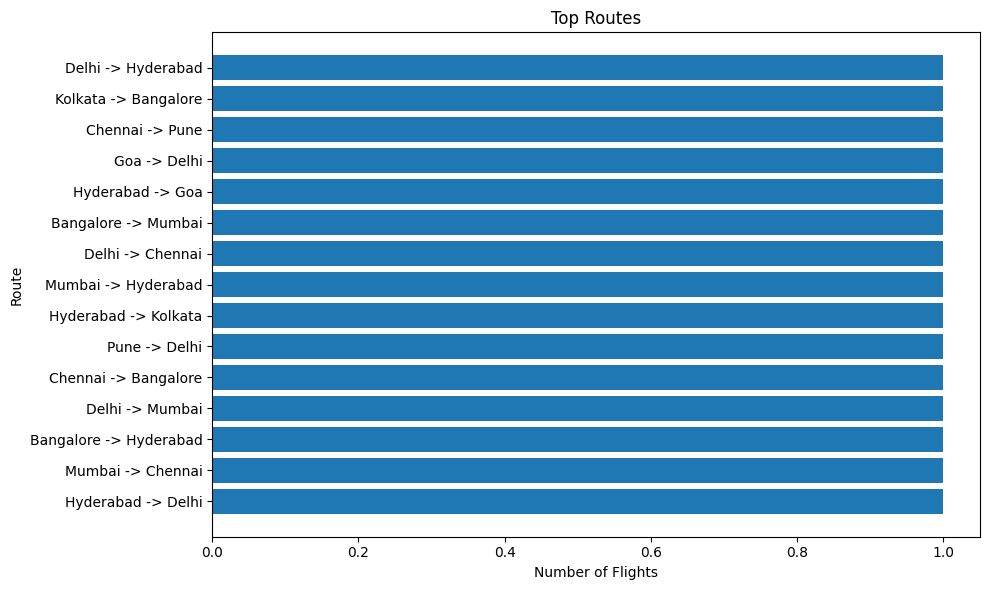

In [0]:
top_routes = fligths_df.withColumn(
    "route",
    concat_ws(" -> ", col("from_city"), col("to_city"))
).groupBy("route").agg(
    count("*").alias("flight_count")
).orderBy(col("flight_count").desc())

top_routes_pd = top_routes.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(
    top_routes_pd["route"],
    top_routes_pd["flight_count"]
)
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.title("Top Routes")
plt.tight_layout()
plt.show()

In [0]:
top_routes.show()

+--------------------+------------+
|               route|flight_count|
+--------------------+------------+
| Bangalore -> Mumbai|           1|
|Kolkata -> Bangalore|           1|
|Hyderabad -> Kolkata|           1|
|    Delhi -> Chennai|           1|
|    Hyderabad -> Goa|           1|
|     Chennai -> Pune|           1|
|  Hyderabad -> Delhi|           1|
|     Delhi -> Mumbai|           1|
|Bangalore -> Hyde...|           1|
| Mumbai -> Hyderabad|           1|
|   Mumbai -> Chennai|           1|
|       Pune -> Delhi|           1|
|Chennai -> Bangalore|           1|
|        Goa -> Delhi|           1|
|  Delhi -> Hyderabad|           1|
+--------------------+------------+



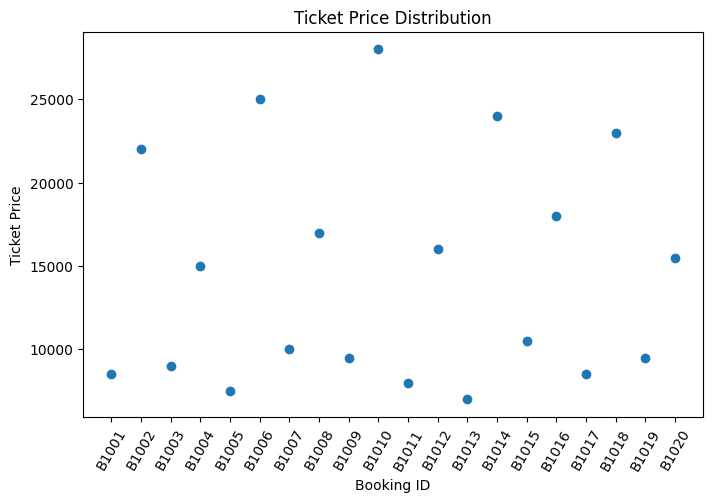

In [0]:
ticket_price_pd = bookings_df.select(
    "booking_id",
    "ticket_price"
).toPandas()

plt.figure(figsize=(8,5))

plt.scatter(
    ticket_price_pd["booking_id"],
    ticket_price_pd["ticket_price"]
)

plt.xlabel("Booking ID")
plt.xticks(rotation=60)
plt.ylabel("Ticket Price")
plt.title("Ticket Price Distribution")
plt.show()

In [0]:
bookings_df.withColumn(
    "revenue",
    col("ticket_price")
).withColumn(
    "price_band",
    when(col("ticket_price") > 20000, "Premium")
    .when(col("ticket_price") > 10000, "Standard")
    .otherwise("Budget")
).show()

+----------+---------+--------------+---------------+------------+------------+-------+----------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|revenue|price_band|
+----------+---------+--------------+---------------+------------+------------+-------+----------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|   8500|    Budget|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|  22000|   Premium|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|   9000|    Budget|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|  15000|  Standard|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|   7500|    Budget|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|  25000|   Premium|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|  10000|    Budget|
|     B100

In [0]:
fligths_df.withColumn(
    'delay_flag',
    when(col('status') == 'Delayed', 'Yes')
    .otherwise('No')
).show()

+---------+---------+---------+---------+--------+---------+----------+
|flight_id|  airline|from_city|  to_city|duration|   status|delay_flag|
+---------+---------+---------+---------+--------+---------+----------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|       Yes|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|        No|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|        No|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|        No|
|     F106|    Akasa|     Pune|    Delhi|     150|  Delayed|       Yes|
|     F107|  Vistara|Hyderabad|  Kolkata|     160|  On Time|        No|
|     F108|   Indigo|   Mumbai|Hyderabad|     110|  On Time|        No|
|     F109|    Akasa|    Delhi|  Chennai|     145|  Delayed|       Yes|
|     F110|Air India|Bangalore|   Mumbai|      95|  On Time|        No|
|     F111|   Indigo|Hyderabad|      Goa|      75|  On Time|    

In [0]:
complete_passenger_journey_dataset = bookings_df.join(
    fligths_df,
    'flight_id',
    'left'
).join(
    preferences_df,
    'passenger_name',
    'left'
)
complete_passenger_journey_dataset.show()

+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+---------+-------------+-------+------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|  airline|from_city|  to_city|duration|   status|extra_baggage|   meal|  seat|
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+---------+-------------+-------+------+
|  Rahul Sharma|     F101|     B1001|        Economy|        8500|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|  On Time|         true|    Veg|Window|
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|  On Time|        false|Non-Veg| Aisle|
|    Amit Kumar|     F102|     B1003|        Economy|        9000|  2026-06-02|Air India|   Mumbai|  Chennai|     120|  Delayed|        false|    Veg|Middle|
|   Sneha Patel|     F103|     B1004|Premium Economy

In [0]:
fligths_df.createOrReplaceTempView('fligths')
bookings_df.createOrReplaceTempView('bookings')
preferences_df.createOrReplaceTempView('preferences')

In [0]:
%sql

select airline, sum(ticket_price) as revenue from bookings
join flights on bookings.flight_id = flights.flight_id
group by airline;

airline,revenue
Air India,68000
Akasa,62000
Indigo,90000
Vistara,71500


In [0]:
%sql

select from_city, to_city, sum(ticket_price) as revenue from bookings
join flights on bookings.flight_id = flights.flight_id
group by from_city, to_city;

from_city,to_city,revenue
Delhi,Chennai,28000
Hyderabad,Delhi,39000
Goa,Delhi,7000
Delhi,Mumbai,7500
Mumbai,Chennai,9000
Pune,Delhi,10000
Bangalore,Mumbai,23500
Delhi,Hyderabad,18000
Kolkata,Bangalore,10500
Chennai,Bangalore,25000


In [0]:
%sql

select avg(ticket_price) as avg_price from bookings;

avg_price
14575.0


In [0]:
%sql

select to_city as most_popular_destination from bookings
join flights on bookings.flight_id = flights.flight_id
group by to_city
order by count(*) desc
limit 1;

most_popular_destination
Delhi


In [0]:
from pyspark.sql.window import Window

flight_revenue = complete_passenger_journey_dataset.groupBy(
    "flight_id"
).agg(sum("ticket_price").alias("revenue"))

win_spec = Window.orderBy(col("revenue").desc())

flight_revenue.withColumn(
    "rank",
    row_number().over(win_spec)
).filter(col("rank") <= 3).show()

route_df = complete_passenger_journey_dataset.groupBy(
    "airline",
    "from_city",
    "to_city"
).agg(count("*").alias("route_count"))

win_spec = Window.partitionBy("airline").orderBy(col("route_count").desc())

route_df.withColumn(
    "rank",
    rank().over(win_spec)
).filter(col("rank") == 1).show()



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-------+----+
|flight_id|revenue|rank|
+---------+-------+----+
|     F101|  39000|   1|
|     F103|  38000|   2|
|     F109|  28000|   3|
+---------+-------+----+

+---------+---------+---------+-----------+----+
|  airline|from_city|  to_city|route_count|rank|
+---------+---------+---------+-----------+----+
|Air India|Bangalore|   Mumbai|          2|   1|
|    Akasa|    Delhi|  Chennai|          1|   1|
|    Akasa|     Pune|    Delhi|          1|   1|
|    Akasa|  Chennai|     Pune|          1|   1|
|   Indigo|Hyderabad|    Delhi|          3|   1|
|  Vistara|Hyderabad|  Kolkata|          2|   1|
|  Vistara|Bangalore|Hyderabad|          2|   1|
+---------+---------+---------+-----------+----+



In [0]:
win_spec = Window.orderBy(
    "booking_id"
).rowsBetween(
    Window.unboundedPreceding,
    Window.currentRow
)

bookings_df.withColumn(
    "running_revenue",
    sum("ticket_price").over(win_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+---------+--------------+---------------+------------+------------+---------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|running_revenue|
+----------+---------+--------------+---------------+------------+------------+---------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|           8500|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|          30500|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|          39500|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|          54500|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|          62000|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|          87000|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|          97000|
|     B1008|     F107|    Meera Nair|Pre

In [0]:
airline_revenue = complete_passenger_journey_dataset.groupBy(
    "airline"
).agg(sum("ticket_price").alias("revenue"))

win_spec = Window.orderBy(col("revenue").desc())

airline_revenue.withColumn(
    "rank",
    rank().over(win_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-------+----+
|  airline|revenue|rank|
+---------+-------+----+
|   Indigo|  90000|   1|
|  Vistara|  71500|   2|
|Air India|  68000|   3|
|    Akasa|  62000|   4|
+---------+-------+----+



In [0]:
destination_df = complete_passenger_journey_dataset.groupBy(
    "to_city"
).agg(count("*").alias("booking_count"))

win_spec = Window.orderBy(col("booking_count").desc())

destination_df.withColumn(
    "dense_rank",
    dense_rank().over(win_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-------------+----------+
|  to_city|booking_count|dense_rank|
+---------+-------------+----------+
|    Delhi|            5|         1|
|Hyderabad|            4|         2|
|   Mumbai|            3|         3|
|  Chennai|            2|         4|
|  Kolkata|            2|         4|
|Bangalore|            2|         4|
|     Pune|            1|         5|
|      Goa|            1|         5|
+---------+-------------+----------+



In [0]:
bookings_df.write.format('delta').mode('overwrite') \
        .save('/Volumes/learn_databricks_7405613655466590/delta_tmp/delta_vol')

bookings_df.write.format('delta').mode('overwrite') \
        .saveAsTable('bookings_delta')

In [0]:
%sql
CREATE TABLE employees_delta (
    emp_id INT,
    name STRING,
    salary INT
)
USING DELTA;

INSERT INTO employees_delta
VALUES
(101,'Rahul',75000),
(102,'Priya',85000);

num_affected_rows,num_inserted_rows
2,2


In [0]:
day2_data = [
    # Existing bookings (updates)
    ("B001", "F101", "Rahul Sharma", "Economy", 13500, "2025-06-02"),
    ("B005", "F103", "Priya Nair", "Business", 22000, "2025-06-02"),
    ("B012", "F105", "Arjun Kumar", "Economy", 12500, "2025-06-02"),
    ("B020", "F107", "Sneha Reddy", "Business", 26000, "2025-06-02"),
    ("B030", "F102", "Vikram Singh", "Economy", 14500, "2025-06-02"),

    # 10 New bookings
    ("B101", "F108", "Ananya Das", "Economy", 11000, "2025-06-02"),
    ("B102", "F109", "Rohit Verma", "Business", 24000, "2025-06-02"),
    ("B103", "F110", "Meera Iyer", "Economy", 9500, "2025-06-02"),
    ("B104", "F111", "Karan Gupta", "Business", 21000, "2025-06-02"),
    ("B105", "F112", "Pooja Menon", "Economy", 10500, "2025-06-02"),
    ("B106", "F113", "Amit Joshi", "Economy", 9800, "2025-06-02"),
    ("B107", "F114", "Neha Kapoor", "Business", 27000, "2025-06-02"),
    ("B108", "F115", "Sanjay Rao", "Economy", 12000, "2025-06-02"),
    ("B109", "F101", "Divya Patel", "Business", 23000, "2025-06-02"),
    ("B110", "F104", "Akash Jain", "Economy", 8900, "2025-06-02")
]

bookings_day2_df = spark.createDataFrame(
    day2_data,
    [
        "booking_id",
        "flight_id",
        "passenger_name",
        "travel_class",
        "ticket_price",
        "booking_date"
    ]
).withColumn(
    "booking_date",
    to_date("booking_date")
)

In [0]:
from delta.tables import DeltaTable

delta_table = DeltaTable.forName(
    spark,
    "bookings_delta"
)

delta_table.alias("target").merge(
    bookings_day2_df.alias("source"),
    "target.booking_id = source.booking_id"
).whenMatchedUpdateAll() \
 .whenNotMatchedInsertAll() \
 .execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
v0 = spark.read.format("delta").option('versionAsOf', 0).table('bookings_delta')
v1 = spark.read.format("delta").option('versionAsOf', 1).table('bookings_delta')
last_v = spark.read.format("delta").table('bookings_delta')

print("Row count before merge :", v0.count())
print("Row count after merge  :", last_v.count())
print("New rows inserted      :", last_v.count() - v0.count())

Row count before merge : 20
Row count after merge  : 35
New rows inserted      : 15


In [0]:
last_v.orderBy('booking_id').show(100, truncate=False)

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|travel_class   |ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|B001      |F101     |Rahul Sharma  |Economy        |13500       |2025-06-02  |
|B005      |F103     |Priya Nair    |Business       |22000       |2025-06-02  |
|B012      |F105     |Arjun Kumar   |Economy        |12500       |2025-06-02  |
|B020      |F107     |Sneha Reddy   |Business       |26000       |2025-06-02  |
|B030      |F102     |Vikram Singh  |Economy        |14500       |2025-06-02  |
|B1001     |F101     |Rahul Sharma  |Economy        |8500        |2026-06-01  |
|B1002     |F101     |Priya Reddy   |Business       |22000       |2026-06-01  |
|B1003     |F102     |Amit Kumar    |Economy        |9000        |2026-06-02  |
|B1004     |F103     |Sneha Patel   |Premium Economy|15000       |2026-06-02  |
|B1005     |F104     |Farhan Ali    |Eco

In [0]:
%sql 
optimize bookings_delta;

optimize bookings_delta
zorder by travel_class;

vacuum bookings_delta;

path
""


In [0]:
%sql
DESCRIBE HISTORY bookings_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
4,2026-06-19T10:50:48.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM END,Map(status -> COMPLETED),null,List(804473306789408),855ae043-f66e-42d9-bb88-ad519056e6b5,0619-090219-cg9g9isl-v2n,3,SnapshotIsolation,true,"Map(numDeletedFiles -> 0, numVacuumedDirectories -> 1)",null,Databricks-Runtime/18.2.x-photon-scala2.13
3,2026-06-19T10:50:47.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM START,"Map(retentionCheckEnabled -> true, defaultRetentionMillis -> 604800000)",null,List(804473306789408),855ae043-f66e-42d9-bb88-ad519056e6b5,0619-090219-cg9g9isl-v2n,2,SnapshotIsolation,true,"Map(numFilesToDelete -> 0, sizeOfDataToDelete -> 0)",null,Databricks-Runtime/18.2.x-photon-scala2.13
2,2026-06-19T10:50:39.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> false, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(804473306789408),6b501ff5-8ded-48aa-8741-7e45e786feb5,0619-090219-cg9g9isl-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 9, numRemovedBytes -> 18749, p25FileSize -> 2747, numDeletionVectorsRemoved -> 0, minFileSize -> 2747, numAddedFiles -> 1, maxFileSize -> 2747, p75FileSize -> 2747, p50FileSize -> 2747, numAddedBytes -> 2747)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-19T10:38:34.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(booking_id#15008 = booking_id#15038)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> true, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(804473306789408),ef58127e-77b1-4953-89cf-bf1a8f65aff4,0619-090219-cg9g9isl-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 8, numTargetBytesAdded -> 16182, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 0, numTargetRowsMatchedUpdated -> 0, executionTimeMs -> 3172, materializeSourceTimeMs -> 249, numTargetRowsInserted -> 15, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1638, numTargetRowsUpdated -> 0, numOutputRows -> 15, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 15, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1191)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-19T10:29:45.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(804473306789408),5abde17d-bae9-41f0-a716-809afd6e6daa,0619-090219-cg9g9isl-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 20, numOutputBytes -> 2567)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
bookings_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("managed_bookings")

In [0]:
bookings_df.write.format("delta") \
    .mode("overwrite") \
    .save("/Volumes/learn_databricks_7405613655466590/delta_tmp/delta_vol")

In [0]:
"""%sql
CREATE TABLE external_bookings
USING DELTA
LOCATION 'dbfs://Volumes/learn_databricks_7405613655466590/delta_tmp/delta_vol/';"""

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8419107886710440>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', "CREATE TABLE external_bookings\nUSING DELTA\nLOCATION 'dbfs://Volumes/learn_databricks_7405613655466590/delta_tmp/delta_vol/';\n")

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magic.py:213, in SqlMagic.sql(self

In [0]:
bookings_df.createOrReplaceTempView("temp_bookings")
#bookings_df.createOrReplaceGlobalTempView("global_bookings")

In [0]:
bookings_day2_df.printSchema()

root
 |-- booking_id: string (nullable = true)
 |-- flight_id: string (nullable = true)
 |-- passenger_name: string (nullable = true)
 |-- travel_class: string (nullable = true)
 |-- ticket_price: long (nullable = true)
 |-- booking_date: date (nullable = true)



In [0]:
fligths_df.printSchema()
bookings_df.printSchema()
preferences_df.printSchema()

root
 |-- flight_id: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- from_city: string (nullable = true)
 |-- to_city: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- booking_id: string (nullable = true)
 |-- flight_id: string (nullable = true)
 |-- passenger_name: string (nullable = true)
 |-- travel_class: string (nullable = true)
 |-- ticket_price: integer (nullable = true)
 |-- booking_date: date (nullable = true)

root
 |-- extra_baggage: boolean (nullable = true)
 |-- meal: string (nullable = true)
 |-- passenger_name: string (nullable = true)
 |-- seat: string (nullable = true)

